##HR: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

### Import Libraries

In [ ]:
# import pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Mount Google Drive/Load DataFrame

In [ ]:
#mount the Google drive on colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the diabetes.csv dataset from google drive into a dataframe named df
df = pd.read_csv('/content/drive/MyDrive/CIS475/Loan_approval_data_2025.csv')

### Sanity Check

In [ ]:
df.shape

(50000, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [ ]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,34.957060,11.118603,18.000,26.000,35.000,43.00000,70.000
years_employed,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
annual_income,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
credit_score,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
credit_history_years,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
savings_assets,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
current_debt,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
defaults_on_file,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
delinquencies_last_2yrs,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
derogatory_marks,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


### Data Preprocessing

In [ ]:
df = df.drop('customer_id', axis=1)

### Logistic Regression

In [ ]:
x = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
x = pd.get_dummies(
    x,
    columns=['occupation_status', 'product_type', 'loan_intent'],
    dtype = 'int8',
    )

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {x_train.shape[0]}')
print(f'x_test shape: {x_test.shape[0]}')

x_train shape: 35000
x_test shape: 15000


In [ ]:
print(f'y_train shape: {y_train.shape[0]}')
print(f'y_test shape: {y_test.shape[0]}')

y_train shape: 35000
y_test shape: 15000


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0         1         2         3        4         5         6  \
0 -0.003951  0.034295  0.000043  0.003414  0.06967  0.000007 -0.000096   

          7         8         9        10        11        12       13  \
0 -0.019993 -0.088594 -0.028934 -0.000023 -0.159706 -0.007008 -0.01574   

         14        15        16        17        18        19        20  \
0 -0.005248 -0.010454 -0.002393  0.000868  0.036613 -0.023764 -0.024829   

         21        22        23        24       25        26  intecept  
0 -0.014494 -0.015162  0.017371 -0.003597 -0.00439  0.008293 -0.011979  


In [ ]:
model_score = model.score(x_test, y_test)
print(model_score)

0.7350666666666666


<Axes: >

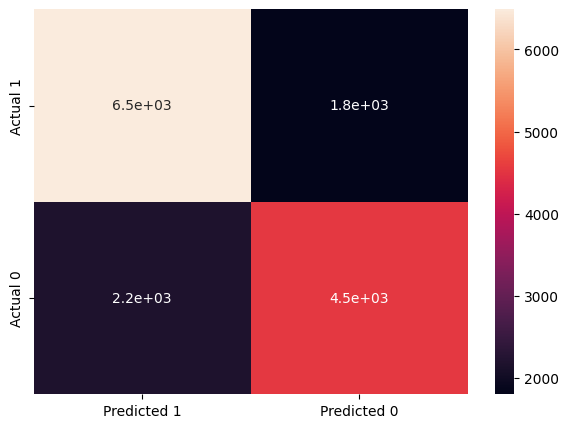

In [ ]:
cm=metrics.confusion_matrix(y_test,y_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.72      0.68      0.70      6712
           1       0.75      0.78      0.77      8288

    accuracy                           0.74     15000
   macro avg       0.73      0.73      0.73     15000
weighted avg       0.73      0.74      0.73     15000



In [ ]:
f1_score(y_test, y_predict)

0.7656010381031025

In [ ]:
accuracy_score(y_test, y_predict)

0.7350666666666666

In [ ]:
precision_score(y_test, y_predict)

0.7489037618278329

In [ ]:
recall_score(y_test, y_predict)

0.7830598455598455

In [ ]:
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

In [ ]:
dfStd = df.copy()

In [ ]:
dfStd.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [ ]:
colStd = ['annual_income', 'credit_score', 'savings_assets', 'current_debt', 'loan_amount']

In [ ]:
for col in colStd:
  dfStd[col] = std_scaler.fit_transform(dfStd[[col]])

dfStd.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,Employed,17.2,-0.750345,0.747482,5.3,-0.204093,-0.262046,0,0,0,Credit Card,Business,-1.242226,17.02,0.423,0.023,0.008,1
1,33,Employed,7.3,-0.213787,-0.256675,3.5,-0.258959,0.170615,0,1,0,Personal Loan,Home Improvement,0.775700,14.10,0.384,1.237,0.412,0
2,42,Student,1.1,-0.895579,0.701137,8.4,-0.270446,-0.486154,0,0,0,Credit Card,Debt Consolidation,-1.184790,18.33,0.377,0.101,0.034,1
3,53,Student,0.5,-0.640998,0.747482,9.8,-0.159883,-0.202923,0,1,0,Credit Card,Business,-1.154157,18.74,0.398,0.099,0.033,1
4,32,Employed,12.5,0.416612,-0.210330,7.2,-0.255936,-0.140931,0,0,0,Personal Loan,Education,2.548565,13.92,0.195,1.565,0.522,1


In [ ]:
xStd = dfStd.drop('loan_status', axis=1)
yStd = dfStd['loan_status']

In [ ]:
xStd = pd.get_dummies(
    xStd,
    columns=['occupation_status', 'product_type', 'loan_intent'],
    dtype = 'int8',
    )

In [ ]:
xStd_train, xStd_test, yStd_train, yStd_test = train_test_split(xStd, yStd, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {xStd_train.shape[0]}')
print(f'x_test shape: {xStd_test.shape[0]}')

x_train shape: 35000
x_test shape: 15000


In [ ]:
print(f'y_train shape: {yStd_train.shape[0]}')
print(f'y_test shape: {yStd_test.shape[0]}')

y_train shape: 35000
y_test shape: 15000


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(xStd_train, yStd_train)

yStd_predict = model.predict(xStd_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0        1        2         3        4         5         6  \
0  0.002932  0.03886  0.45606  0.835474  0.10231  0.114033 -0.596937   

          7         8         9        10        11        12        13  \
0 -8.253506 -0.882154 -1.173139  0.114495 -0.436222 -7.856501 -1.804676   

         14        15        16        17        18        19        20  \
0 -0.604961  1.702645  1.727245  1.862896  4.413908 -0.100236  0.979114   

        21       22        23        24        25        26  intecept  
0  0.01419 -0.76479  2.494328  0.885564  0.892265  1.771229  5.292785  


In [ ]:
model_score = model.score(xStd_test, yStd_test)
print(model_score)

0.8662


<Axes: >

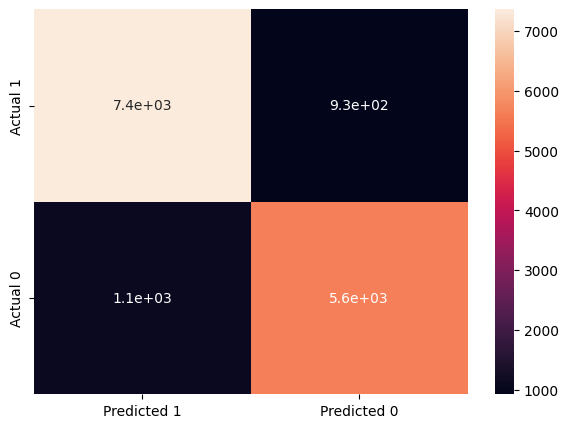

In [ ]:
cm=metrics.confusion_matrix(yStd_test,yStd_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(yStd_test, yStd_predict))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      6712
           1       0.87      0.89      0.88      8288

    accuracy                           0.87     15000
   macro avg       0.87      0.86      0.86     15000
weighted avg       0.87      0.87      0.87     15000



In [ ]:
f1_score(yStd_test, yStd_predict)

0.8800286926893418

In [ ]:
accuracy_score(yStd_test, yStd_predict)

0.8662

In [ ]:
precision_score(yStd_test, yStd_predict)

0.8720530742802985

In [ ]:
recall_score(yStd_test, yStd_predict)

0.8881515444015444

In [ ]:
dfMM = df.copy()

In [ ]:
for col in colStd:
  dfMM[col] = min_max_scaler.fit_transform(dfMM[[col]])

dfMM.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,Employed,17.2,0.045017,0.685259,5.3,0.002983,0.065897,0,0,0,Credit Card,Business,0.001005,17.02,0.423,0.023,0.008,1
1,33,Employed,7.3,0.119519,0.555777,3.5,0.000563,0.100990,0,1,0,Personal Loan,Home Improvement,0.530653,14.10,0.384,1.237,0.412,0
2,42,Student,1.1,0.024851,0.679283,8.4,0.000057,0.047721,0,0,0,Credit Card,Debt Consolidation,0.016080,18.33,0.377,0.101,0.034,1
3,53,Student,0.5,0.060200,0.685259,9.8,0.004933,0.070693,0,1,0,Credit Card,Business,0.024121,18.74,0.398,0.099,0.033,1
4,32,Employed,12.5,0.207051,0.561753,7.2,0.000697,0.075721,0,0,0,Personal Loan,Education,0.995980,13.92,0.195,1.565,0.522,1


In [ ]:
xMM = dfMM.drop('loan_status', axis=1)
yMM = dfMM['loan_status']

In [ ]:
xMM = pd.get_dummies(
    xMM,
    columns=['occupation_status', 'product_type', 'loan_intent'],
    dtype = 'int8',
    )

In [ ]:
xMM_train, xMM_test, yMM_train, yMM_test = train_test_split(xMM, yMM, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {xMM_train.shape[0]}')
print(f'x_test shape: {xMM_test.shape[0]}')

x_train shape: 35000
x_test shape: 15000


In [ ]:
print(f'y_train shape: {yMM_train.shape[0]}')
print(f'y_test shape: {yMM_test.shape[0]}')

y_train shape: 35000
y_test shape: 15000


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(xMM_train, yMM_train)

yMM_predict = model.predict(xMM_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0         1         2         3         4         5        6  \
0  0.003097  0.038443  1.916186  5.834772  0.102644  2.025213 -4.76516   

          7         8         9        10        11        12        13  \
0 -8.011681 -0.876745 -1.166034  0.571418 -0.466708 -8.565297 -1.851276   

        14        15        16        17        18        19        20  \
0 -0.62206  1.183703  1.217422  1.334307  4.032648 -0.717164  0.419948   

         21        22        23        24        25       26  intecept  
0 -0.241436 -1.014545  2.225341  0.626599  0.634762  1.50471  3.735432  


In [ ]:
model_score = model.score(xMM_test, yMM_test)
print(model_score)

0.8655333333333334


<Axes: >

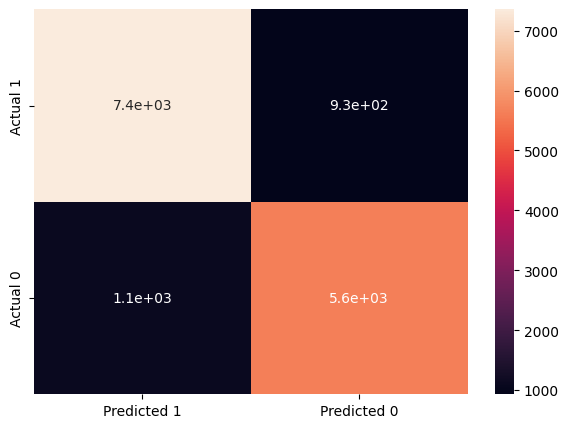

In [ ]:
cm=metrics.confusion_matrix(yMM_test,yMM_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(yMM_test, yMM_predict))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      6712
           1       0.87      0.89      0.88      8288

    accuracy                           0.87     15000
   macro avg       0.86      0.86      0.86     15000
weighted avg       0.87      0.87      0.87     15000



In [ ]:
f1_score(yMM_test, yMM_predict)

0.8794165122257428

In [ ]:
accuracy_score(yMM_test, yMM_predict)

0.8655333333333334

In [ ]:
precision_score(yMM_test, yMM_predict)

0.8715487617016234

In [ ]:
recall_score(yMM_test, yMM_predict)

0.8874276061776062

###Lets move on to our second Dataset

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/CIS475/Raisin_Dataset.csv')

In [ ]:
df2.shape

(900, 8)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [ ]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,900.0,87804.127778,39002.111390,25387.000000,59348.000000,78902.000000,105028.250000,235047.000000
MajorAxisLength,900.0,430.929950,116.035121,225.629541,345.442898,407.803951,494.187014,997.291941
MinorAxisLength,900.0,254.488133,49.988902,143.710872,219.111126,247.848409,279.888575,492.275279
Eccentricity,900.0,0.781542,0.090318,0.348730,0.741766,0.798846,0.842571,0.962124
ConvexArea,900.0,91186.090000,40769.290132,26139.000000,61513.250000,81651.000000,108375.750000,278217.000000
Extent,900.0,0.699508,0.053468,0.379856,0.670869,0.707367,0.734991,0.835455
Perimeter,900.0,1165.906636,273.764315,619.074000,966.410750,1119.509000,1308.389750,2697.753000


In [ ]:
for feature in df2.columns: # Loop through all columns in dataframe
  if df2[feature].dtype == 'object': #Only apply for columns of type object
    df2[feature] = pd.Categorical(df2[feature]) #Replace string with a category
df2.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
df2['Class'] = df2['Class'].replace("Kecimen", 1)

/tmp/ipykernel_440/2306146708.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df2['Class'] = df2['Class'].replace("Kecimen", 1)


In [ ]:
df2['Class'] = df2['Class'].replace("Besni", 0)

/tmp/ipykernel_440/4082798392.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Class'] = df2['Class'].replace("Besni", 0)
/tmp/ipykernel_440/4082798392.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df2['Class'] = df2['Class'].replace("Besni", 0)


In [ ]:
x = df2.drop('Class', axis=1)
y = df2['Class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {x_train.shape[0]}')
print(f'x_test shape: {x_test.shape[0]}')

x_train shape: 630
x_test shape: 270


In [ ]:
print(f'y_train shape: {y_train.shape[0]}')
print(f'y_test shape: {y_test.shape[0]}')

y_train shape: 630
y_test shape: 270


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0         1         2         3         4         5         6  \
0  0.000335 -0.006287  0.039088  0.000035 -0.000473  0.000143  0.004696   

   intecept  
0  0.000146  


In [ ]:
model_score = model.score(x_test, y_test)
print(model_score)

0.8925925925925926


<Axes: >

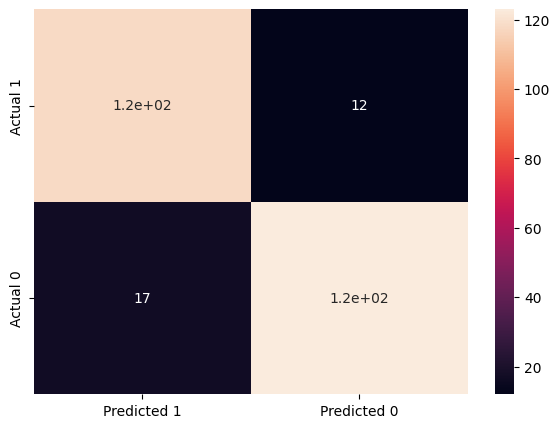

In [ ]:
cm=metrics.confusion_matrix(y_test,y_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89       140
           1       0.87      0.91      0.89       130

    accuracy                           0.89       270
   macro avg       0.89      0.89      0.89       270
weighted avg       0.89      0.89      0.89       270



In [ ]:
f1_score(y_test, y_predict)

0.8905660377358491

In [ ]:
accuracy_score(y_test, y_predict)

0.8925925925925926

In [ ]:
precision_score(y_test, y_predict)

0.8740740740740741

In [ ]:
recall_score(y_test, y_predict)

0.9076923076923077

In [ ]:
dfStd = df2.copy()

In [ ]:
dfStd.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,1
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,1
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,1
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,1
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,1


In [ ]:
colStd = ['Area', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'Perimeter']

In [ ]:
for col in colStd:
  dfStd[col] = std_scaler.fit_transform(dfStd[[col]])

dfStd.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,-0.007186,0.097577,-0.023958,0.819738,-0.015709,0.758651,0.066274,1
1,-0.324217,-0.209012,-0.229292,0.801805,-0.304248,0.684130,-0.161252,1
2,0.078292,0.097758,0.236988,0.798354,0.062113,0.637613,0.155945,1
3,-1.074286,-1.245051,-0.915273,0.684989,-1.076165,0.699599,-1.175915,1
4,-0.215393,-0.678958,0.727354,0.564011,-0.238623,0.792772,-0.338639,1


In [ ]:
xStd = dfStd.drop('Class', axis=1)
yStd = dfStd['Class']

In [ ]:
xStd_train, xStd_test, yStd_train, yStd_test = train_test_split(xStd, yStd, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {xStd_train.shape[0]}')
print(f'x_test shape: {xStd_test.shape[0]}')

x_train shape: 630
x_test shape: 270


In [ ]:
print(f'y_train shape: {yStd_train.shape[0]}')
print(f'y_test shape: {yStd_test.shape[0]}')

y_train shape: 630
y_test shape: 270


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(xStd_train, yStd_train)

yStd_predict = model.predict(xStd_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0         1         2        3         4         5         6  \
0 -0.409255 -0.697626  1.016795 -0.35949 -0.736702  0.068356 -2.299955   

   intecept  
0 -0.292124  


In [ ]:
model_score = model.score(xStd_test, yStd_test)
print(model_score)

0.8962962962962963


<Axes: >

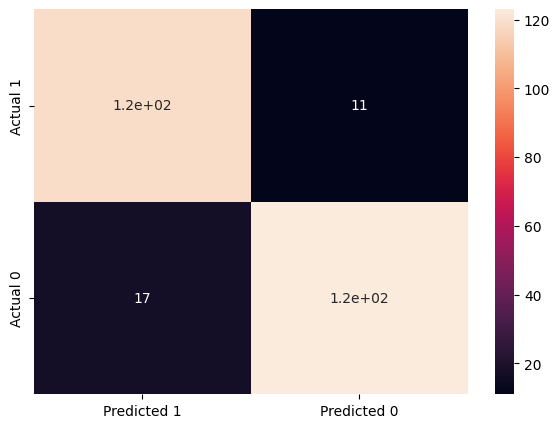

In [ ]:
cm=metrics.confusion_matrix(yStd_test,yStd_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(yStd_test, yStd_predict))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       140
           1       0.88      0.92      0.89       130

    accuracy                           0.90       270
   macro avg       0.90      0.90      0.90       270
weighted avg       0.90      0.90      0.90       270



In [ ]:
f1_score(yStd_test, yStd_predict)

0.8947368421052632

In [ ]:
accuracy_score(yStd_test, yStd_predict)

0.8962962962962963

In [ ]:
precision_score(yStd_test, yStd_predict)

0.875

In [ ]:
recall_score(yStd_test, yStd_predict)

0.9153846153846154

In [ ]:
dfMM = df2.copy()

In [ ]:
for col in colStd:
  dfMM[col] = min_max_scaler.fit_transform(dfMM[[col]])

dfMM.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,0.296370,0.280714,0.314376,0.819738,0.255504,0.758651,0.271791,1
1,0.237427,0.234638,0.284945,0.801805,0.208864,0.684130,0.241842,1
2,0.312263,0.280741,0.351778,0.798354,0.268084,0.637613,0.283594,1
3,0.097973,0.078935,0.186620,0.684989,0.084089,0.699599,0.108284,1
4,0.257660,0.164011,0.422064,0.564011,0.219472,0.792772,0.218493,1


In [ ]:
xMM = dfMM.drop('Class', axis=1)
yMM = dfMM['Class']

In [ ]:
xMM_train, xMM_test, yMM_train, yMM_test = train_test_split(xMM, yMM, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {xMM_train.shape[0]}')
print(f'x_test shape: {xMM_test.shape[0]}')

x_train shape: 630
x_test shape: 270


In [ ]:
print(f'y_train shape: {yMM_train.shape[0]}')
print(f'y_test shape: {yMM_test.shape[0]}')

y_train shape: 630
y_test shape: 270


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(xMM_train, yMM_train)

yMM_predict = model.predict(xMM_test)

coef_df = pd.DataFrame(model.coef_)
coef_df['intecept'] = model.intercept_
print(coef_df)

          0         1         2         3         4         5         6  \
0 -3.043093 -3.816562 -0.266915 -1.378754 -2.749185  2.606644 -3.044373   

   intecept  
0  2.501562  


In [ ]:
model_score = model.score(xMM_test, yMM_test)
print(model_score)

0.8962962962962963


<Axes: >

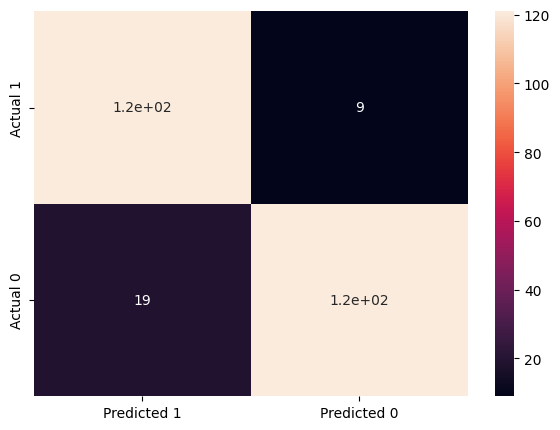

In [ ]:
cm=metrics.confusion_matrix(yMM_test,yMM_predict, labels=[1,0])

df_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [ ]:
print(classification_report(yMM_test, yMM_predict))

              precision    recall  f1-score   support

           0       0.93      0.86      0.90       140
           1       0.86      0.93      0.90       130

    accuracy                           0.90       270
   macro avg       0.90      0.90      0.90       270
weighted avg       0.90      0.90      0.90       270



In [ ]:
f1_score(yMM_test, yMM_predict)

0.8962962962962963

In [ ]:
accuracy_score(yMM_test, yMM_predict)

0.8962962962962963

In [ ]:
precision_score(yMM_test, yMM_predict)

0.8642857142857143

In [ ]:
recall_score(yMM_test, yMM_predict)

0.9307692307692308

## Third Dataset

In [ ]:
#df3 = pd.read_csv('/content/drive/MyDrive/MLSP26FINAL/DATA/Heart_disease_cleveland_new.csv')
df3 = pd.read_csv('/content/drive/MyDrive/CIS475/Heart_disease_cleveland_new.csv')

In [ ]:
df3.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df3.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Baseline Model


In [ ]:
x3 = df3.drop('target', axis=1)
y3 = df3['target']

In [ ]:
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {x3_train.shape[0]}')
print(f'x_test shape: {x3_test.shape[0]}')

x_train shape: 212
x_test shape: 91


In [ ]:
print(f'y_train shape: {y3_train.shape[0]}')
print(f'y_test shape: {y3_test.shape[0]}')

y_train shape: 212
y_test shape: 91


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(x3_train, y3_train)

y3_predict = model.predict(x3_test)

coef_df3 = pd.DataFrame(model.coef_)
coef_df3['intecept'] = model.intercept_
print(coef_df3)

          0         1         2         3         4         5         6  \
0 -0.027283  1.096217  0.441324  0.009516  0.002654 -0.161768  0.168773   

          7         8         9        10        11        12  intecept  
0 -0.029116  0.929661  0.415887  0.185893  1.024141  0.514102 -0.370482  


In [ ]:
model_score = model.score(x3_test, y3_test)
print(model_score)

0.8681318681318682


<Axes: >

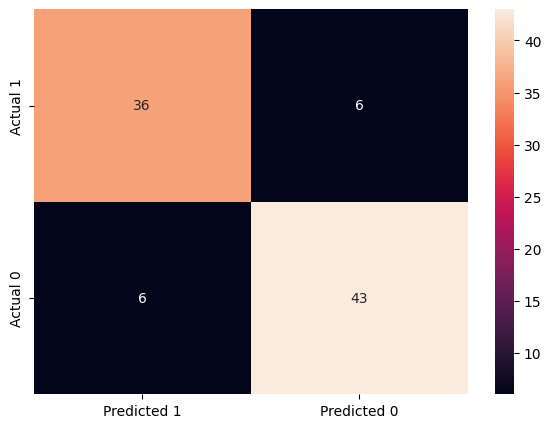

In [ ]:
cm=metrics.confusion_matrix(y3_test,y3_predict, labels=[1,0])

df3_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df3_cm, annot=True)

In [ ]:
print(classification_report(y3_test, y3_predict))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        49
           1       0.86      0.86      0.86        42

    accuracy                           0.87        91
   macro avg       0.87      0.87      0.87        91
weighted avg       0.87      0.87      0.87        91



In [ ]:
f1_score(y3_test, y3_predict)

0.8571428571428571

In [ ]:
accuracy_score(y3_test, y3_predict)

0.8681318681318682

In [ ]:
precision_score(y3_test, y3_predict)

0.8571428571428571

In [ ]:
recall_score(y3_test, y3_predict)

0.8571428571428571

### Standardized

In [ ]:
df3std = df3.copy()

In [ ]:
df3.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [ ]:
colTransformation = ['age', 'trestbps', 'chol', 'thalach']

In [ ]:
for col in colTransformation:
  df3std[col] = std_scaler.fit_transform(df3std[[col]])

df3std.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.948726,1,0,0.757525,-0.264900,1,2,0.017197,0,2.3,2,0,2,0
1,1.392002,1,3,1.611220,0.760415,0,2,-1.821905,1,1.5,1,3,1,1
2,1.392002,1,3,-0.665300,-0.342283,0,2,-0.902354,1,2.6,1,2,3,1
3,-1.932564,1,2,-0.096170,0.063974,0,0,1.637359,0,3.5,2,0,1,0
4,-1.489288,0,1,-0.096170,-0.825922,0,2,0.980537,0,1.4,0,0,1,0


In [ ]:
x3std = df3.drop('target', axis=1)
y3std = df3['target']

In [ ]:
x3std_train, x3std_test, y3std_train, y3std_test = train_test_split(x3std, y3std, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {x3std_train.shape[0]}')
print(f'x_test shape: {x3std_test.shape[0]}')

x_train shape: 212
x_test shape: 91


In [ ]:
print(f'y_train shape: {y3std_train.shape[0]}')
print(f'y_test shape: {y3std_test.shape[0]}')

y_train shape: 212
y_test shape: 91


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(x3std_train, y3std_train)

y3std_predict = model.predict(x3std_test)

coef_df3std = pd.DataFrame(model.coef_)
coef_df3std['intecept'] = model.intercept_
print(coef_df3std)

          0         1         2         3         4         5         6  \
0 -0.027283  1.096217  0.441324  0.009516  0.002654 -0.161768  0.168773   

          7         8         9        10        11        12  intecept  
0 -0.029116  0.929661  0.415887  0.185893  1.024141  0.514102 -0.370482  


In [ ]:
model_score = model.score(x3std_test, y3std_test)
print(model_score)

0.8681318681318682


<Axes: >

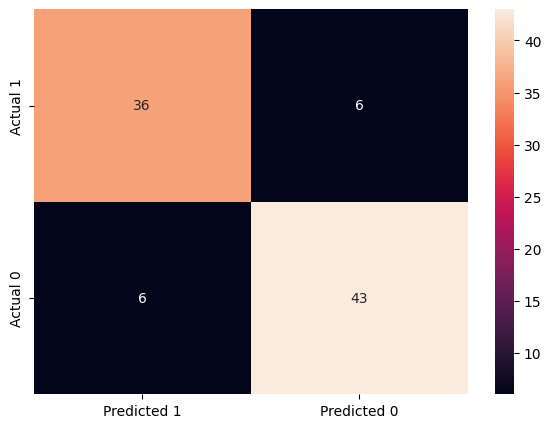

In [ ]:
cm=metrics.confusion_matrix(y3std_test,y3std_predict, labels=[1,0])

df3std_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df3std_cm, annot=True)

In [ ]:
print(classification_report(y3std_test, y3std_predict))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        49
           1       0.86      0.86      0.86        42

    accuracy                           0.87        91
   macro avg       0.87      0.87      0.87        91
weighted avg       0.87      0.87      0.87        91



In [ ]:
f1_score(y3std_test, y3std_predict)

0.8571428571428571

In [ ]:
accuracy_score(y3std_test, y3std_predict)

0.8681318681318682

In [ ]:
precision_score(y3std_test, y3std_predict)

0.8571428571428571

In [ ]:
recall_score(y3std_test, y3std_predict)

0.8571428571428571

### MinMax Scaled

In [ ]:
df3mm = df3.copy()

In [ ]:
for col in colTransformation:
  df3mm[col] = min_max_scaler.fit_transform(df3mm[[col]])

df3mm.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.708333,1,0,0.481132,0.244292,1,2,0.603053,0,2.3,2,0,2,0
1,0.791667,1,3,0.622642,0.365297,0,2,0.282443,1,1.5,1,3,1,1
2,0.791667,1,3,0.245283,0.235160,0,2,0.442748,1,2.6,1,2,3,1
3,0.166667,1,2,0.339623,0.283105,0,0,0.885496,0,3.5,2,0,1,0
4,0.250000,0,1,0.339623,0.178082,0,2,0.770992,0,1.4,0,0,1,0


In [ ]:
x3mm = df3mm.drop('target', axis=1)
y3mm = df3mm['target']

In [ ]:
x3mm_train, x3mm_test, y3mm_train, y3mm_test = train_test_split(x3mm, y3mm, test_size=0.3, random_state = 1)

In [ ]:
print(f'x_train shape: {x3mm_train.shape[0]}')
print(f'x_test shape: {x3mm_test.shape[0]}')

x_train shape: 212
x_test shape: 91


In [ ]:
print(f'y_train shape: {y3mm_train.shape[0]}')
print(f'y_test shape: {y3mm_test.shape[0]}')

y_train shape: 212
y_test shape: 91


In [ ]:
model = LogisticRegression(solver="liblinear", random_state=0)
model.fit(x3mm_train, y3mm_train)

y3mm_predict = model.predict(x3mm_test)

coef_df3mm = pd.DataFrame(model.coef_)
coef_df3mm['intecept'] = model.intercept_
print(coef_df3mm)

         0         1         2         3        4         5         6  \
0 -0.55755  0.782678  0.311845  0.184937 -0.03385 -0.247064  0.138288   

          7         8         9        10        11        12  intecept  
0 -1.964677  0.973292  0.425272  0.175631  0.929822  0.476102 -2.218882  


In [ ]:
model_score = model.score(x3mm_test, y3mm_test)
print(model_score)

0.8681318681318682


<Axes: >

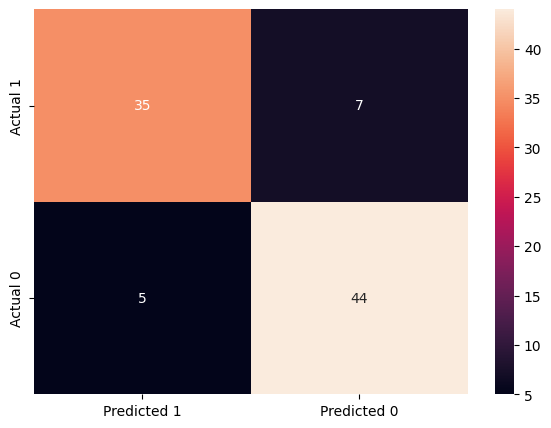

In [ ]:
cm=metrics.confusion_matrix(y3mm_test,y3mm_predict, labels=[1,0])

df3mm_cm = pd.DataFrame(cm, index = [i for i in ['Actual 1', "Actual 0"]],
                  columns = [i for i in ["Predicted 1", "Predicted 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df3mm_cm, annot=True)

In [ ]:
print(classification_report(y3mm_test, y3mm_predict))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        49
           1       0.88      0.83      0.85        42

    accuracy                           0.87        91
   macro avg       0.87      0.87      0.87        91
weighted avg       0.87      0.87      0.87        91



In [ ]:
f1_score(y3mm_test, y3mm_predict)

0.8536585365853658

In [ ]:
accuracy_score(y3mm_test, y3mm_predict)

0.8681318681318682

In [ ]:
precision_score(y3mm_test, y3mm_predict)

0.875

In [ ]:
recall_score(y3mm_test, y3mm_predict)

0.8333333333333334

### Model Comparison

In [ ]:
# Helper function to get metrics
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

all_metrics = []

# Re-mount Google Drive to ensure file access
from google.colab import drive
drive.mount('/content/drive')

# --- Dataset 3: Heart_disease_cleveland_new.csv ---
df3_base = pd.read_csv('/content/drive/MyDrive/CIS475/Heart_disease_cleveland_new.csv')

x3 = df3_base.drop('target', axis=1)
y3 = df3_base['target']
x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.3, random_state = 1)
model3 = LogisticRegression(solver="liblinear", random_state=0)
model3.fit(x3_train, y3_train)
y3_predict = model3.predict(x3_test)
metrics3_base = get_metrics(y3_test, y3_predict)
metrics3_base['Dataset'] = 'Heart Disease'
metrics3_base['Scaling'] = 'None'
all_metrics.append(metrics3_base)

# Dataset 3: Standard Scaler
df3_std = df3_base.copy()
col_to_scale_df3 = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in col_to_scale_df3:
  df3_std[col] = std_scaler.fit_transform(df3_std[[col]])

x3_std = df3_std.drop('target', axis=1)
y3_std = df3_std['target']
x3_std_train, x3_std_test, y3_std_train, y3_std_test = train_test_split(x3_std, y3_std, test_size=0.3, random_state = 1)
model3_std = LogisticRegression(solver="liblinear", random_state=0)
model3_std.fit(x3_std_train, y3_std_train)
y3_std_predict = model3_std.predict(x3_std_test)
metrics3_std = get_metrics(y3_std_test, y3_std_predict)
metrics3_std['Dataset'] = 'Heart Disease'
metrics3_std['Scaling'] = 'StandardScaler'
all_metrics.append(metrics3_std)

# Dataset 3: MinMax Scaler
df3_mm = df3_base.copy()
for col in col_to_scale_df3:
  df3_mm[col] = min_max_scaler.fit_transform(df3_mm[[col]])

x3_mm = df3_mm.drop('target', axis=1)
y3_mm = df3_mm['target']
x3_mm_train, x3_mm_test, y3_mm_train, y3_mm_test = train_test_split(x3_mm, y3_mm, test_size=0.3, random_state = 1)
model3_mm = LogisticRegression(solver="liblinear", random_state=0)
model3_mm.fit(x3_mm_train, y3_mm_train)
y3_mm_predict = model3_mm.predict(x3_mm_test)
metrics3_mm = get_metrics(y3_mm_test, y3_mm_predict)
metrics3_mm['Dataset'] = 'Heart Disease'
metrics3_mm['Scaling'] = 'MinMaxScaler'
all_metrics.append(metrics3_mm)

# Create a DataFrame from the collected metrics
comparison_df = pd.DataFrame(all_metrics)

print("\n--- Model Performance Comparison (Heart Disease Dataset) ---")
display(comparison_df.set_index(['Dataset', 'Scaling']))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Model Performance Comparison (Heart Disease Dataset) ---


Accuracy  Precision    Recall  F1-Score
Dataset       Scaling                                                
Heart Disease None            0.868132   0.857143  0.857143  0.857143
              StandardScaler  0.846154   0.833333  0.833333  0.833333
              MinMaxScaler    0.857143   0.837209  0.857143  0.847059